# Profiles and Segmentation

Build weekly, daily, and seasonal load profiles from grid (netload) data; compare across seasons and regions; segment households by grid behavior; cluster circuits and daily regimes within a house.

## Setup

Load one or more regions, run cleaning pipeline (adds calendar features), optionally merge metadata for segmentation.

In [22]:
import sys
from pathlib import Path

root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import PROJECT_ROOT, WHOLE_HOME_COLUMN, REGIONS
from src.loaders import load_15min_data, load_metadata, merge_data_with_metadata
from src.cleaning import run_cleaning_pipeline, get_season
from src.profiling import (
    build_daily_profile,
    build_seasonal_profile,
    build_weekly_profile,
    household_features_from_grid,
    cluster_households,
    circuit_features_for_home,
    cluster_circuits,
    daily_vectors_for_home,
    cluster_days,
)

In [23]:
# Load one or more regions; use None for full data
SAMPLE_ROWS = None
REGIONS_TO_LOAD = ["austin"]  # or ["austin", "california", "newyork"]

dfs = []
for region in REGIONS_TO_LOAD:
    df = load_15min_data(region)
    if SAMPLE_ROWS:
        df = df.head(SAMPLE_ROWS)
    df, quality = run_cleaning_pipeline(df)
    df["region"] = region
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)

# Optional: merge metadata for segmentation (e.g. square footage, PV)
meta_list = [load_metadata(r) for r in REGIONS_TO_LOAD]
meta = pd.concat(meta_list, ignore_index=True).drop_duplicates(subset=["dataid"])
df = merge_data_with_metadata(df, meta, normalized=True)

print(f"Loaded {len(df)} rows, {df['dataid'].nunique()} households, regions: {df['region'].unique().tolist()}")

Loaded 873286 rows, 25 households, regions: ['austin']


## Profiles

### Weekly profile

Average load by time of week (hour 0–167 or weekday/weekend × hour).

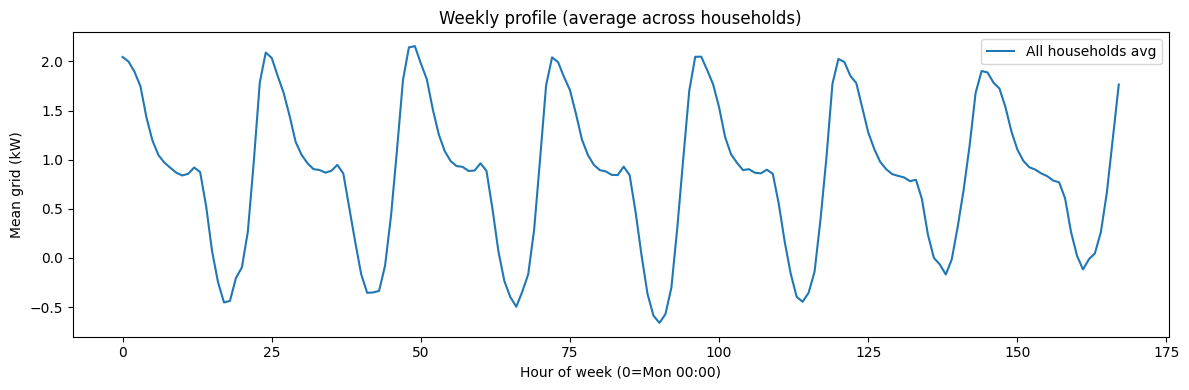

In [24]:
weekly = build_weekly_profile(df, value_col=WHOLE_HOME_COLUMN, use_hour_of_week=True)

# Aggregate across households for "average" weekly curve (optionally by region)
weekly_avg = weekly.groupby("hour_of_week", as_index=False)[WHOLE_HOME_COLUMN].mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_avg["hour_of_week"], weekly_avg[WHOLE_HOME_COLUMN], label="All households avg")
ax.set_xlabel("Hour of week (0=Mon 00:00)")
ax.set_ylabel("Mean grid (kW)")
ax.set_title("Weekly profile (average across households)")
ax.legend()
plt.tight_layout()
plt.show()

### Daily profile

Average load by hour of day (0–23). Optionally filter by season or region.

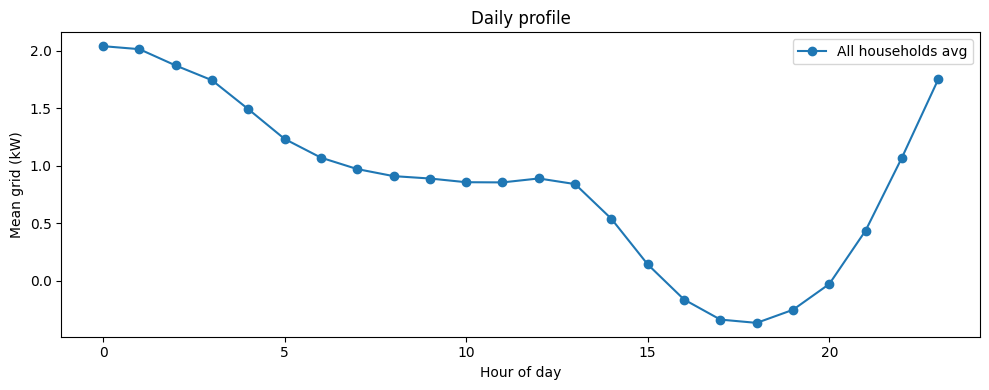

In [25]:
daily = build_daily_profile(df, value_col=WHOLE_HOME_COLUMN)

# Plot: one line per household (sample) or average
daily_avg = daily.groupby("hour", as_index=False)[WHOLE_HOME_COLUMN].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily_avg["hour"], daily_avg[WHOLE_HOME_COLUMN], marker="o", label="All households avg")
if "region" in df.columns and df["region"].nunique() > 1:
    for region in df["region"].unique():
        sub = df[df["region"] == region]
        d = build_daily_profile(sub)
        d_avg = d.groupby("hour", as_index=False)[WHOLE_HOME_COLUMN].mean()
        ax.plot(d_avg["hour"], d_avg[WHOLE_HOME_COLUMN], alpha=0.7, label=f"Region: {region}")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean grid (kW)")
ax.set_title("Daily profile")
ax.legend()
plt.tight_layout()
plt.show()

### Seasonal profile and comparison

Daily profile stratified by season. Compare seasons within one region, or same season across regions.

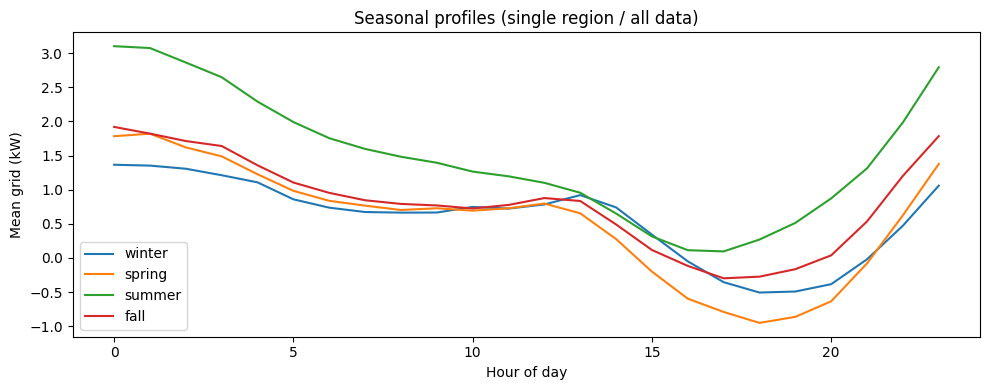

In [26]:
seasonal = build_seasonal_profile(df, value_col=WHOLE_HOME_COLUMN)
# Add season labels for plotting
season_labels = {1: "winter", 2: "spring", 3: "summer", 4: "fall"}
seasonal["season_label"] = seasonal["season"].map(season_labels)

# Single region: compare seasons (all on one axes)
fig, ax = plt.subplots(figsize=(10, 4))
for s in seasonal["season"].unique():
    sl = seasonal[seasonal["season"] == s]
    agg = sl.groupby("hour", as_index=False)[WHOLE_HOME_COLUMN].mean()
    ax.plot(agg["hour"], agg[WHOLE_HOME_COLUMN], label=season_labels.get(s, s))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean grid (kW)")
ax.set_title("Seasonal profiles (single region / all data)")
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# Across regions: compare same season (e.g. summer) or all seasons by region
if "region" in df.columns and df["region"].nunique() > 1:
    seasonal_with_region = seasonal.merge(
        df[["dataid", "region"]].drop_duplicates(), on="dataid", how="left"
    )
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.ravel()
    for i, season in enumerate(sorted(seasonal_with_region["season"].unique())):
        ax = axes[i]
        for region in df["region"].unique():
            sub = seasonal_with_region[(seasonal_with_region["season"] == season) & (seasonal_with_region["region"] == region)]
            if sub.empty:
                continue
            agg = sub.groupby("hour", as_index=False)[WHOLE_HOME_COLUMN].mean()
            ax.plot(agg["hour"], agg[WHOLE_HOME_COLUMN], label=region)
        ax.set_title(season_labels.get(season, season))
        ax.legend()
        ax.set_ylabel("Mean grid (kW)")
    for ax in axes:
        ax.set_xlabel("Hour of day")
    plt.suptitle("Seasonal profiles by region")
    plt.tight_layout()
    plt.show()

## Household segmentation

Segment households (dataids) using grid load behavior: build per-household features, cluster (e.g. KMeans), assign segment labels, plot segment profiles and scatter.

In [28]:
# Per-household features from grid (includes 24-dim load shape)
features = household_features_from_grid(df, value_col=WHOLE_HOME_COLUMN, include_shape_24=True, include_metadata=False)
# Cluster (use shape + scalar features; optionally PCA)
N_SEGMENTS = 4
segment_labels = cluster_households(features, n_clusters=N_SEGMENTS, use_pca=True, n_components=10)
features["segment"] = features["dataid"].map(segment_labels)
print("Segment sizes:", features["segment"].value_counts().sort_index().to_dict())

Segment sizes: {0: 5, 1: 7, 2: 5, 3: 8}


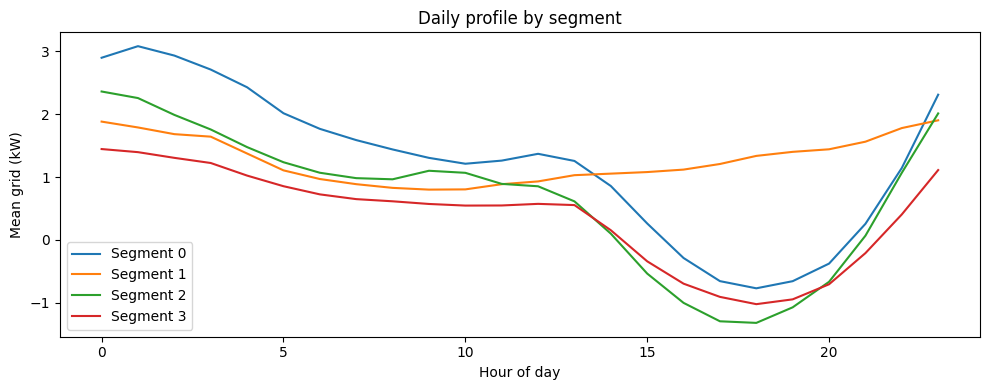

In [29]:
# Merge segment into main df for profile by segment
seg_df = segment_labels.rename("segment").reset_index()
if "dataid" not in seg_df.columns:
    seg_df = seg_df.rename(columns={seg_df.columns[0]: "dataid"})
df_seg = df.merge(seg_df, on="dataid", how="left")
# Typical daily profile per segment (one curve per segment)
daily_seg = build_daily_profile(df_seg, value_col=WHOLE_HOME_COLUMN, group_cols=["segment"])
fig, ax = plt.subplots(figsize=(10, 4))
for seg in sorted(daily_seg["segment"].dropna().unique()):
    sub = daily_seg[daily_seg["segment"] == seg]
    ax.plot(sub["hour"], sub[WHOLE_HOME_COLUMN], label=f"Segment {seg}")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean grid (kW)")
ax.set_title("Daily profile by segment")
ax.legend()
plt.tight_layout()
plt.show()

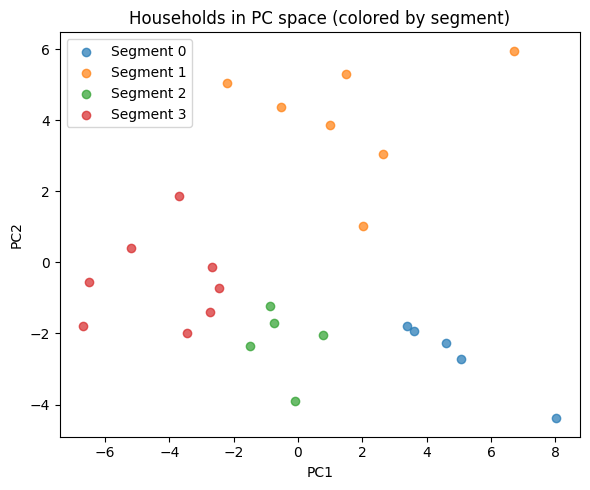

In [30]:
# Optional: scatter of first two PCs colored by segment
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
feat_cols = [c for c in features.select_dtypes(include=[np.number]).columns if c != "dataid"]
X = features[feat_cols].fillna(features[feat_cols].mean())
X = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)
fig, ax = plt.subplots(figsize=(6, 5))
for seg in sorted(features["segment"].dropna().unique()):
    mask = features["segment"] == seg
    ax.scatter(X2[mask, 0], X2[mask, 1], label=f"Segment {seg}", alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Households in PC space (colored by segment)")
ax.legend()
plt.tight_layout()
plt.show()

## Within-house clustering

**A. Circuit-level clustering:** For one household, cluster circuits by mean, std, peak hour, correlation with grid to get appliance groups (e.g. HVAC-like vs plug-load-like).

**B. Temporal regimes:** For one household, cluster days by 96-interval load vector into regimes (e.g. typical weekday, high-use day, weekend).

In [31]:
# Pick one household for within-house analysis
sample_dataid = df["dataid"].iloc[0]

# A. Circuit-level clustering
circuit_feat = circuit_features_for_home(df, sample_dataid, grid_col=WHOLE_HOME_COLUMN)
if not circuit_feat.empty:
    n_circuit_clusters = min(3, len(circuit_feat))
    circuit_clusters = cluster_circuits(
        circuit_feat, n_clusters=n_circuit_clusters,
        feature_cols=["mean_kw", "std_kw", "peak_hour", "corr_with_grid"]
    )
    circuit_feat["cluster"] = circuit_feat["circuit"].map(circuit_clusters)
    print(f"Circuit clusters for dataid={sample_dataid}:")
    print(circuit_feat[["circuit", "cluster", "mean_kw", "peak_hour"]].to_string())
else:
    print("No circuit data for this household.")

Circuit clusters for dataid=661:
           circuit  cluster   mean_kw  peak_hour
0             air1        2  0.440973         23
1         furnace1        1  0.174256         23
2   clotheswasher1        0  0.004585          1
3      dishwasher1        0  0.004938          2
4        disposal1        0  0.000000          0
5            drye1        1  0.040863         23
6       microwave1        0  0.006317         15
7    refrigerator1        0  0.058184          1
8        bathroom1        0  0.003933         13
9      kitchenapp1        0  0.003956          1
10     kitchenapp2        0  0.006623          2


/Volumes/DevBlocks/projects/Pecan/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Volumes/DevBlocks/projects/Pecan/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Daily regimes for dataid=661:
regime
0    126
1    119
2    121
Name: count, dtype: int64


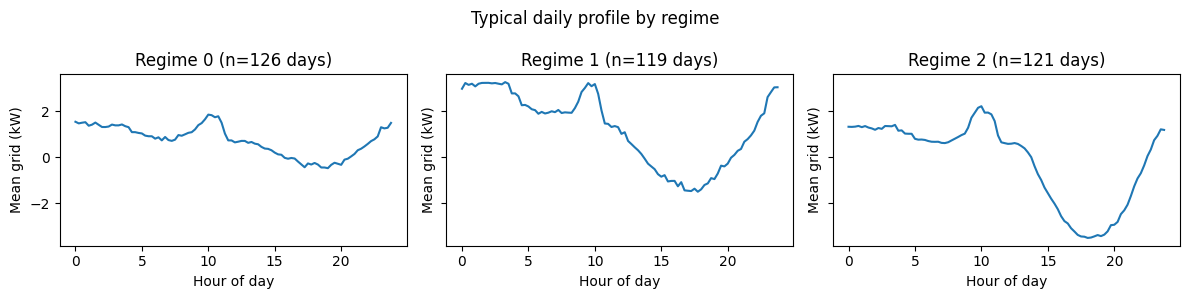

In [32]:
# B. Daily regime clustering (temporal regimes within one house)
daily_vec = daily_vectors_for_home(df, sample_dataid, value_col=WHOLE_HOME_COLUMN)
if len(daily_vec) >= 3:
    n_regimes = min(3, len(daily_vec))
    regime_labels = cluster_days(daily_vec, n_clusters=n_regimes, use_pca=True, n_components=10)
    daily_vec["regime"] = daily_vec["date"].map(regime_labels)
    print(f"Daily regimes for dataid={sample_dataid}:")
    print(daily_vec["regime"].value_counts().sort_index())
    # Plot typical profile per regime (mean of 96 intervals)
    fig, axes = plt.subplots(1, n_regimes, figsize=(4 * n_regimes, 3), sharey=True)
    if n_regimes == 1:
        axes = [axes]
    for i, reg in enumerate(sorted(daily_vec["regime"].unique())):
        sub = daily_vec[daily_vec["regime"] == reg]
        vec_cols = [c for c in daily_vec.columns if c.startswith("interval_")]
        mean_profile = sub[vec_cols].mean().values
        axes[i].plot(np.arange(96) / 4, mean_profile)  # 15-min -> hours on x
        axes[i].set_xlabel("Hour of day")
        axes[i].set_ylabel("Mean grid (kW)")
        axes[i].set_title(f"Regime {reg} (n={len(sub)} days)")
    plt.suptitle("Typical daily profile by regime")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough days for regime clustering.")